# QuAC Dataset Exploration

Question Answering in Context (~84K QA turns across ~12K dialogues).  
Conversational QnA — each row is a multi-turn dialogue over a Wikipedia passage.  
Can be flattened to single-turn extractive format; ~17% of turns are unanswerable (`CANNOTANSWER`).  
HuggingFace: `quac`

Columns: `dialogue_id`, `wikipedia_page_title`, `background`, `section_title`, `context`, `questions` (list), `answers` (list of dicts), `orig_answers`, `followups`, `yesnos`, `turn_ids`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from pprint import pprint
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

In [3]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)

QUAC_HF_ID = 'quac'
tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'DATA_PATH: {DATA_PATH}')
print(f'QUAC_HF_ID: {QUAC_HF_ID}')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

DATA_PATH: Q:\data
QUAC_HF_ID: quac
Tokenizer vocab size: 30522


## Load QuAC

In [4]:
# Load QuAC from HuggingFace
ds_quac = load_dataset(QUAC_HF_ID, cache_dir=str(DATA_PATH), trust_remote_code=True)
print(f'Splits: {list(ds_quac.keys())}')
for split_name, split_ds in ds_quac.items():
    n_turns = sum(len(split_ds[i]['questions']) for i in range(len(split_ds)))
    print(f'  {split_name}: {len(split_ds)} dialogues, {n_turns} QA turns')
print(f'\nFeatures: {list(ds_quac["train"].features.keys())}')

Splits: ['train', 'validation']
  train: 11567 dialogues, 83568 QA turns
  validation: 1000 dialogues, 7354 QA turns

Features: ['dialogue_id', 'wikipedia_page_title', 'background', 'section_title', 'context', 'turn_ids', 'questions', 'followups', 'yesnos', 'answers', 'orig_answers']


In [5]:
# Examine the structure of one dialogue
ex = ds_quac['train'][0]
print('Keys:', list(ex.keys()))
print()
print(f'dialogue_id: {ex["dialogue_id"]}')
print(f'wikipedia_page_title: {ex["wikipedia_page_title"]}')
print(f'section_title: {ex["section_title"]}')
print(f'background: {ex["background"][:200]}...')
print(f'context: {ex["context"][:300]}...')
print(f'Number of turns: {len(ex["questions"])}')
print()
for i in range(min(3, len(ex['questions']))):
    q = ex['questions'][i]
    orig_a = ex['orig_answers']['texts'][i]
    a_start = ex['orig_answers']['answer_starts'][i]
    print(f'  Turn {i}: Q="{q}"')
    print(f'           A="{orig_a}" (start={a_start})')
    print()

Keys: ['dialogue_id', 'wikipedia_page_title', 'background', 'section_title', 'context', 'turn_ids', 'questions', 'followups', 'yesnos', 'answers', 'orig_answers']

dialogue_id: C_69758fcdfc1f46baba0e92c0f3b0919c_1
wikipedia_page_title: Malayali
section_title: Geographic distribution and population
background: The Malayali people or Keralite people (also spelt Malayalee, Malayalam script: mlyaalli and keerlliiy[?]) are an Indian ethnic group originating from the present-day state of Kerala, located in South...
context: According to the Indian census of 2001, there were 30,803,747 speakers of Malayalam in Kerala, making up 93.2% of the total number of Malayalam speakers in India, and 96.7% of the total population of the state. There were a further 701,673 (2.1% of the total number) in Karnataka, 557,705 (1.7%) in T...
Number of turns: 7

  Turn 0: Q="Where is Malayali located?"
           A="30,803,747 speakers of Malayalam in Kerala, making up 93.2% of the total number of Malayalam spea

## Dataset Statistics

In [6]:
# Dataset statistics
ds_train = ds_quac['train']

n_dialogues = len(ds_train)
turns_per_dialogue = [len(ds_train[i]['questions']) for i in range(n_dialogues)]
total_turns = sum(turns_per_dialogue)

# Count CANNOTANSWER (unanswerable) turns
n_cannot = 0
for i in range(n_dialogues):
    for txt in ds_train[i]['orig_answers']['texts']:
        if txt == 'CANNOTANSWER':
            n_cannot += 1

n_answerable = total_turns - n_cannot
n_unique_pages = len(set(ds_train[i]['wikipedia_page_title'] for i in range(n_dialogues)))

print(f'Train dialogues: {n_dialogues}')
print(f'Total QA turns: {total_turns}')
print(f'Answerable turns: {n_answerable} ({n_answerable/total_turns:.1%})')
print(f'CANNOTANSWER turns: {n_cannot} ({n_cannot/total_turns:.1%})')
print(f'Unique Wikipedia pages: {n_unique_pages}')
print(f'Avg turns per dialogue: {total_turns / n_dialogues:.1f}')

Train dialogues: 11567
Total QA turns: 83568
Answerable turns: 69109 (82.7%)
CANNOTANSWER turns: 14459 (17.3%)
Unique Wikipedia pages: 2991
Avg turns per dialogue: 7.2


Turns per dialogue: mean=7.2, median=7, min=4, max=12, std=2.1

4     1373
5     1482
6     1620
7     1660
8     2488
9     1306
10     689
11     610
12     339
Name: count, dtype: int64

Answer char lengths (answerable): mean=90.1, median=92, max=239


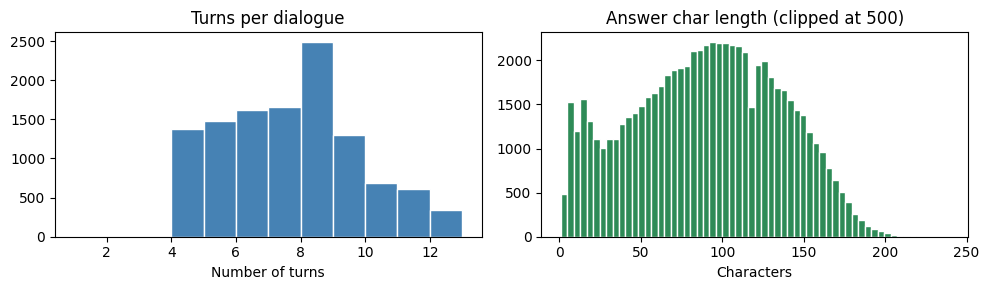

In [7]:
# Turns-per-dialogue distribution
turns_arr = np.array(turns_per_dialogue)
print(f'Turns per dialogue: mean={turns_arr.mean():.1f}, median={np.median(turns_arr):.0f}, '
      f'min={turns_arr.min()}, max={turns_arr.max()}, std={turns_arr.std():.1f}')
print()
print(pd.Series(turns_arr).value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(turns_arr, bins=range(1, turns_arr.max() + 2), color='steelblue', edgecolor='white')
axes[0].set_title('Turns per dialogue')
axes[0].set_xlabel('Number of turns')

# Answer char length distribution (answerable only)
ans_char_lens = []
for i in range(n_dialogues):
    for txt in ds_train[i]['orig_answers']['texts']:
        if txt != 'CANNOTANSWER':
            ans_char_lens.append(len(txt))
ans_char_lens = np.array(ans_char_lens)
print(f'\nAnswer char lengths (answerable): mean={ans_char_lens.mean():.1f}, median={np.median(ans_char_lens):.0f}, '
      f'max={ans_char_lens.max()}')

axes[1].hist(np.clip(ans_char_lens, 0, 500), bins=60, color='seagreen', edgecolor='white')
axes[1].set_title('Answer char length (clipped at 500)')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

## Inspect Examples (Conversational Turns)

In [8]:
# Display a few full dialogues
for d_idx in range(3):
    ex = ds_train[d_idx]
    print(f'=== Dialogue {d_idx}: {ex["wikipedia_page_title"]} / {ex["section_title"]} ===')
    print(f'  Background: {ex["background"][:200]}...')
    print(f'  Context: {ex["context"][:300]}...')
    print()

    n_turns = len(ex['questions'])
    for t_idx in range(n_turns):
        q = ex['questions'][t_idx]
        orig_a = ex['orig_answers']['texts'][t_idx]
        a_start = ex['orig_answers']['answer_starts'][t_idx]
        followup = ['y', 'n', 'm'][ex['followups'][t_idx]]
        yesno = ['y', 'n', 'x'][ex['yesnos'][t_idx]]

        is_cannot = orig_a == 'CANNOTANSWER'
        tag = ' [CANNOTANSWER]' if is_cannot else ''

        # Show answer in context
        if not is_cannot:
            ctx_off = 40
            beg = max(a_start - ctx_off, 0)
            ctx_around = ex['context'][beg:a_start + len(orig_a) + ctx_off]
            ctx_snip = f'  ...{ctx_around}...'
        else:
            ctx_snip = ''

        print(f'  Turn {t_idx}: Q: "{q}"')
        print(f'           A: "{orig_a[:150]}"{tag}  (followup={followup}, yesno={yesno})')
        if ctx_snip:
            print(f'           Context: "{ctx_snip}"')
    print()

=== Dialogue 0: Malayali / Geographic distribution and population ===
  Background: The Malayali people or Keralite people (also spelt Malayalee, Malayalam script: mlyaalli and keerlliiy[?]) are an Indian ethnic group originating from the present-day state of Kerala, located in South...
  Context: According to the Indian census of 2001, there were 30,803,747 speakers of Malayalam in Kerala, making up 93.2% of the total number of Malayalam speakers in India, and 96.7% of the total population of the state. There were a further 701,673 (2.1% of the total number) in Karnataka, 557,705 (1.7%) in T...

  Turn 0: Q: "Where is Malayali located?"
           A: "30,803,747 speakers of Malayalam in Kerala, making up 93.2% of the total number of Malayalam speakers in India,"  (followup=m, yesno=x)
           Context: "  ...o the Indian census of 2001, there were 30,803,747 speakers of Malayalam in Kerala, making up 93.2% of the total number of Malayalam speakers in India, and 96.7% of the total po

## Flatten to Single-Turn QnA Pairs

In [9]:
# Flatten dialogues into single-turn (context, question, answer) rows
# Use orig_answers (single annotator answer used as gold standard)
# Skip CANNOTANSWER turns for the extractive QnA use case
rows_flat = []
for i in range(len(ds_train)):
    ex = ds_train[i]
    context = ex['context']
    for t_idx in range(len(ex['questions'])):
        question = ex['questions'][t_idx]
        answer = ex['orig_answers']['texts'][t_idx]
        answer_start = ex['orig_answers']['answer_starts'][t_idx]
        is_cannot = answer == 'CANNOTANSWER'
        rows_flat.append({
            'context': context,
            'question': question,
            'answer': answer,
            'answer_start': answer_start,
            'is_unanswerable': is_cannot,
            'dialogue_id': ex['dialogue_id'],
            'turn_idx': t_idx,
            'wikipedia_page_title': ex['wikipedia_page_title'],
        })

df_flat = pd.DataFrame(rows_flat)
n_answerable = (~df_flat['is_unanswerable']).sum()
print(f'Flattened rows: {len(df_flat)}')
print(f'  Answerable: {n_answerable} ({n_answerable/len(df_flat):.1%})')
print(f'  Unanswerable: {df_flat["is_unanswerable"].sum()} ({df_flat["is_unanswerable"].mean():.1%})')
print()
df_flat.head(10)

Flattened rows: 83568
  Answerable: 69109 (82.7%)
  Unanswerable: 14459 (17.3%)



,context,question,answer,answer_start,is_unanswerable,dialogue_id,turn_idx,wikipedia_page_title
0,"According to the Indian census of 2001, there ...",Where is Malayali located?,"30,803,747 speakers of Malayalam in Kerala, ma...",51,False,C_69758fcdfc1f46baba0e92c0f3b0919c_1,0,Malayali
1,"According to the Indian census of 2001, there ...",What other languages are spoken there?,"33,015,420 spoke the standard dialects, 19,643...",640,False,C_69758fcdfc1f46baba0e92c0f3b0919c_1,1,Malayali
2,"According to the Indian census of 2001, there ...",What else is this place known for?,"World Malayalee Council, the organisation work...",1862,False,C_69758fcdfc1f46baba0e92c0f3b0919c_1,2,Malayali
3,"According to the Indian census of 2001, there ...",Were they ever successful in doing this?,CANNOTANSWER,2024,True,C_69758fcdfc1f46baba0e92c0f3b0919c_1,3,Malayali
4,"According to the Indian census of 2001, there ...",Do they produce anything from here?,CANNOTANSWER,2024,True,C_69758fcdfc1f46baba0e92c0f3b0919c_1,4,Malayali
5,"According to the Indian census of 2001, there ...",Is this population still growing?,"In 2010, the Census of Population of Singapore...",1461,False,C_69758fcdfc1f46baba0e92c0f3b0919c_1,5,Malayali
6,"According to the Indian census of 2001, there ...",Is the country thriving?,CANNOTANSWER,2024,True,C_69758fcdfc1f46baba0e92c0f3b0919c_1,6,Malayali
7,Malayalam is the language spoken by the Malaya...,what language do they speak?,Malayalam is the language spoken by the Malaya...,0,False,C_69758fcdfc1f46baba0e92c0f3b0919c_0,0,Malayali
8,Malayalam is the language spoken by the Malaya...,Do they speak any other languages?,Malayalam is derived from old Tamil and Sanskr...,51,False,C_69758fcdfc1f46baba0e92c0f3b0919c_0,1,Malayali
9,Malayalam is the language spoken by the Malaya...,any literary items of interest?,Malayalam literature is ancient in origin. The...,478,False,C_69758fcdfc1f46baba0e92c0f3b0919c_0,2,Malayali


In [11]:
# Verify answer spans: check that answer text matches context at answer_start
df_ans = df_flat[~df_flat['is_unanswerable']].copy()
n_mismatch = 0
for _, row in df_ans.head(5000).iterrows():
    ctx = row['context']
    ans = row['answer']
    start = row['answer_start']
    extracted = ctx[start:start + len(ans)]
    if extracted != ans:
        n_mismatch += 1
        if n_mismatch <= 3:
            print(f'MISMATCH: extracted="{extracted[:80]}" vs answer="{ans[:80]}"')

print(f'\nSpan mismatches in first 5000 answerable rows: {n_mismatch}')


Span mismatches in first 5000 answerable rows: 0


## Context / Answer Length Distributions

In [12]:
# Tokenize contexts, questions, answers and measure lengths (answerable only)
df_ans = df_flat[~df_flat['is_unanswerable']].reset_index(drop=True)

quac_ctx_lens = []
quac_q_lens = []
quac_ans_lens = []

for _, row in df_ans.iterrows():
    ctx_toks = tkz(row['context'], add_special_tokens=False).input_ids
    q_toks = tkz(row['question'], add_special_tokens=False).input_ids
    ans_toks = tkz(row['answer'], add_special_tokens=False).input_ids

    quac_ctx_lens.append(len(ctx_toks))
    quac_q_lens.append(len(q_toks))
    quac_ans_lens.append(len(ans_toks))

quac_ctx_lens = np.array(quac_ctx_lens)
quac_q_lens = np.array(quac_q_lens)
quac_ans_lens = np.array(quac_ans_lens)

print(f'Processed {len(quac_ctx_lens)} answerable examples')
print('\nContext token lengths:')
print(f'  mean={quac_ctx_lens.mean():.1f}, median={np.median(quac_ctx_lens):.1f}, '
      f'min={quac_ctx_lens.min()}, max={quac_ctx_lens.max()}, std={quac_ctx_lens.std():.1f}')
print('Question token lengths:')
print(f'  mean={quac_q_lens.mean():.1f}, median={np.median(quac_q_lens):.1f}, '
      f'min={quac_q_lens.min()}, max={quac_q_lens.max()}, std={quac_q_lens.std():.1f}')
print('Answer token lengths:')
print(f'  mean={quac_ans_lens.mean():.1f}, median={np.median(quac_ans_lens):.1f}, '
      f'min={quac_ans_lens.min()}, max={quac_ans_lens.max()}, std={quac_ans_lens.std():.1f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (624 > 512). Running this sequence through the model will result in indexing errors


Processed 69109 answerable examples

Context token lengths:
  mean=518.1, median=482.0, min=291, max=2310, std=199.2
Question token lengths:
  mean=7.7, median=7.0, min=1, max=33, std=2.4
Answer token lengths:
  mean=19.6, median=20.0, min=1, max=75, std=9.9


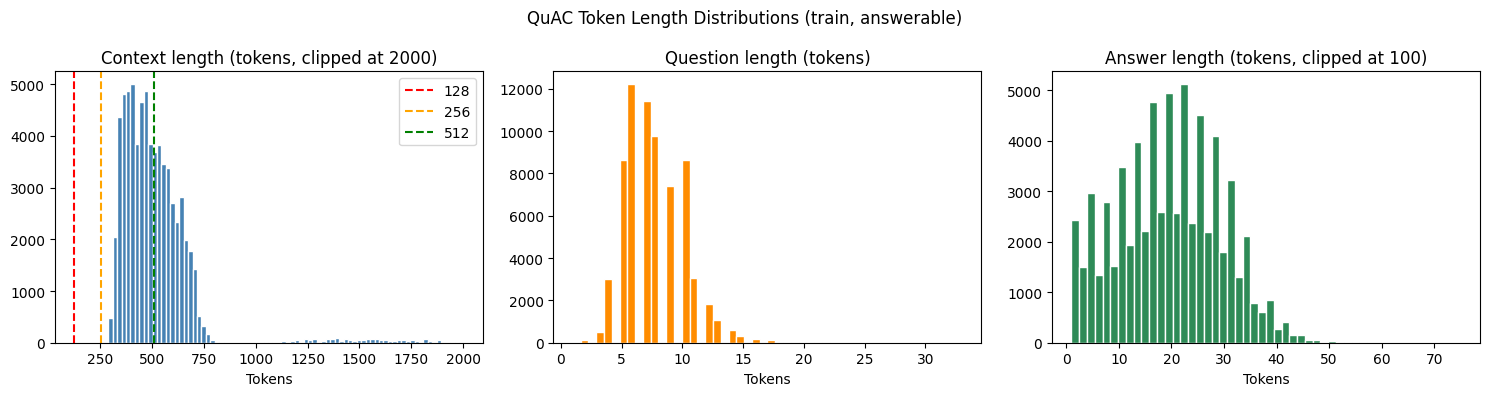

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Context lengths (Wikipedia passages) — clip at 2000
ctx_clip = np.clip(quac_ctx_lens, 0, 2000)
axes[0].hist(ctx_clip, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens, clipped at 2000)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(256, color='orange', linestyle='--', label='256')
axes[0].axvline(512, color='green', linestyle='--', label='512')
axes[0].legend()

axes[1].hist(quac_q_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(np.clip(quac_ans_lens, 0, 100), bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens, clipped at 100)')
axes[2].set_xlabel('Tokens')

plt.suptitle('QuAC Token Length Distributions (train, answerable)')
plt.tight_layout()
plt.show()

In [14]:
# Chunk analysis — how many contexts need multi-chunk processing
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2
    n_chunks = np.ceil(quac_ctx_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(quac_ctx_lens)} ({multi/len(quac_ctx_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.2f}')

inp_len=128: need >1 chunk: 69109/69109 (100.0%), max chunks: 19, mean chunks: 4.60
inp_len=256: need >1 chunk: 69109/69109 (100.0%), max chunks: 10, mean chunks: 2.52
inp_len=384: need >1 chunk: 56178/69109 (81.3%), max chunks: 7, mean chunks: 1.88
inp_len=512: need >1 chunk: 29209/69109 (42.3%), max chunks: 5, mean chunks: 1.46


## Convert to Unified QnA Format

In [ ]:
# Convert QuAC to unified QnA format: (context, question, answer, source)
# Combine train + validation splits; skip CANNOTANSWER turns
rows_unified = []
for split_name in ds_quac.keys():
    ds_split = ds_quac[split_name]
    for i in range(len(ds_split)):
        ex = ds_split[i]
        context = ex['context']
        for t_idx in range(len(ex['questions'])):
            question = ex['questions'][t_idx]
            answer = ex['orig_answers']['texts'][t_idx]
            if answer == 'CANNOTANSWER' or not context.strip() or not question.strip():
                continue
            rows_unified.append({
                'context': context,
                'question': question,
                'answer': answer,
                'source': 'quac',
            })

df_unified_quac = pd.DataFrame(rows_unified)
print(f'Unified QuAC rows (all splits, answerable only): {len(df_unified_quac)}')
df_unified_quac.head()

In [ ]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'quac_unified.parquet'
df_unified_quac.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_quac)} rows)')